# **Séries temporais do sensor *Wide-Field Imager* (WFI) para classificação de áreas queimadas no Cerrado**

### **Classificação com Random Forest [4/5]**

No *notebook* anterior (03_pre_processamento_espectral.ipynb), vimos como extrair e estruturar séries temporais da banda do infravermelho próximo (NIR - *near infrared*) do *dataset* tabular, explorando três abordagens temporais: com dados diários, com dados agregados em 16 dias e com dados agregados em 30 dias.

Agora vamos dar um passo adiante: **usar essas séries temporais como entrada em classificações supervisionadas de áreas queimadas**.

Nosso objetivo é treinar um classificador **Random Forest** para distinguir células queimadas de não queimadas, comparando o desempenho das três abordagens de agregação temporal.

Para compreender melhor o *dataset* explorado, consulte: https://doi.org/10.1080/20964471.2025.2463731

**1) *Download* e preparação dos dados**

Antes de iniciarmos a análise, precisamos obter a base de dados. O conjunto utilizado neste exercício está disponível publicamente e reúne os registros do sensor WFI entre 2020 e 2022... Convertamos o arquivo CSV para Parquet, um formato mais eficiente para leitura e manipulação de grandes volumes de dados.

**Observação**: esse *dataset* contém diversas outras colunas, mas nesse exercício nos focaremos nas colunas que contém as reflectâncias TOA (*top of atmosphere*) da banda NIR (colunas com o prefixo 'd'). Para entender melhor o *dataset*, consulte: https://doi.org/10.1080/20964471.2025.2463731

In [ ]:
# ============================================
# FUNÇÕES AUXILIARES
# ============================================

import requests
from tqdm.auto import tqdm

def download(url: str, output: str) -> None:
    response = requests.get(url, stream=True)
    response.raise_for_status()

    total_size = int(response.headers.get("content-length", 0))

    with open(output, "wb") as f, tqdm(
        total=total_size,
        unit="B",
        unit_scale=True,
        desc=output.split("/")[-1],
    ) as pbar:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            f.write(chunk)
            pbar.update(len(chunk))

# ============================================
# DOWNLOAD E PREPARAÇÃO DOS DADOS
# ============================================

import pandas as pd # trabalha com dataframes
import os

# ----------------------------------------------------------------------------
# CAMINHOS E URLS
# ----------------------------------------------------------------------------

CSV_URL = "https://download.scidb.cn/download?fileId=e22fe8b8fa7b696516664d76a42ac2fe&path=/V4/Dataset_WFI.csv&fileName=Dataset_WFI.csv" # link do dataset no repositório ScienceDB

# Criar diretório no armazenamento temporário do Colab
BASE_DIR = "/content/ScienceDB/Dataset"
csv_path = os.path.join(BASE_DIR, "Dataset_WFI.csv")
parquet_path = os.path.join(BASE_DIR, "Dataset_WFI.parquet")

# Criar diretório se não existir
os.makedirs(BASE_DIR, exist_ok=True)

# ----------------------------------------------------------------------------
# DOWNLOAD E CONVERSÃO DE CSV PARA PARQUET
# ----------------------------------------------------------------------------

if not os.path.exists(parquet_path):
    # Baixar CSV se necessário
    if not os.path.exists(csv_path):
        download(CSV_URL, csv_path)
    else:
        print(f"✓ CSV já existe: {csv_path}")

    # Converter para Parquet (formato mais eficiente)
    print("Convertendo CSV para Parquet...")
    df = pd.read_csv(csv_path)
    df.to_parquet(parquet_path, compression="snappy")

    # Liberar memória e limpar
    del df
    os.remove(csv_path)
    print(f"✓ Parquet salvo: {parquet_path}")
    print(f"✓ CSV removido: {csv_path}") # como o csv é pesado, removemos ele após a conversão para Parquet
else:
    print(f"✓ Parquet já existe: {parquet_path}")

print("\n✓ Arquivo de dados pronto!")

Dataset_WFI.csv:   0%|          | 0.00/2.26G [00:00<?, ?B/s]

Convertendo CSV para Parquet...


/tmp/ipykernel_1112/1162010271.py:58: DtypeWarning: Columns (9856,9857,9858) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


✓ Parquet salvo: /content/ScienceDB/Dataset/Dataset_WFI.parquet
✓ CSV removido: /content/ScienceDB/Dataset/Dataset_WFI.csv

✓ Arquivo de dados pronto!


**2) Preparação dos dados para classificação**

Para cada abordagem (diário, 16 dias, 30 dias), seguiremos os passos:

a) Extração das colunas do NIR para cada ano (2020, 2021 e 2022)

b) Seleção de amostras de células com e sem áreas queimadas

c) Criação da matriz de *features* (séries temporais) e os *labels* (1 = queimada, 0 = não queimada)

d) Preparação dos conjuntos de dados em treino`/validação (2020-2021) e teste (2022)

A função `preparar_dados_classificacao()` automatiza esse processo para cada ano e abordagem de agregação:

Agregação diária: utiliza a série original com 365 observações (reflectância TOA diária);

Agregação em 16 dias: calcula a **média** do NIR a cada **16 dias**, resultando em ~23 observações;

Agregação mensal: calcula a **média** do NIR por **mês**, resultando em 12 observações.

As funções `agregar_16_dias()` e `agregar_por_mes()` aplicam essas reduções, enquanto `combinar_dados()` junta os anos de treino. Com isso, obtemos três conjuntos de dados com diferentes níveis de detalhamento temporal para avaliar qual abordagem produz o melhor modelo de classificação.

Durante o treinamento, reservamos **20% dos dados de treino para validação** (estratificada por classe), garantindo que o modelo seja avaliado em dados não vistos antes do teste final com 2022.

In [ ]:
import os
import numpy as np
import pandas as pd

# ============================================
# FUNÇÕES AUXILIARES PARA PREPARAÇÃO DOS DADOS
# ============================================

BASE_DIR = "/content/ScienceDB/Dataset"
parquet_path = os.path.join(BASE_DIR, "Dataset_WFI.parquet")

def get_nir_cols(ano):
    """Retorna as colunas do NIR para um determinado ano."""
    return sorted([col for col in df.columns if col.startswith(f'd_{str(ano)[-2:]}')])

def get_pico_data(ano):
    """Retorna a data de pico de queimadas para um determinado ano."""
    col = f"date_{str(ano)[-2:]}"
    contagem = df[col].value_counts()
    contagem = contagem[contagem.index.notna()]
    if len(contagem) > 0:
        return contagem.idxmax()
    return None

def agregar_16_dias(serie, nir_cols):
    """
    Agrupa valores em janelas de 16 dias e calcula a média.

    Args:
        serie: Array NumPy com os valores da série temporal.
        nir_cols: Lista de nomes das colunas (usado apenas para determinar o tamanho).
    """
    num_cols = len(nir_cols)
    num_grupos = (num_cols + 15) // 16
    medias = []
    for i in range(num_grupos):
        inicio = i * 16
        fim = min((i + 1) * 16, num_cols)
        medias.append(serie[inicio:fim].mean())
    return np.array(medias)

def agregar_por_mes(serie, nir_cols):
    """
    Agrupa valores por mês e calcula a média.

    Args:
        serie: Array NumPy com os valores da série temporal.
        nir_cols: Lista de nomes das colunas (usado apenas para determinar o tamanho).
    """
    num_cols = len(nir_cols)
    dias_por_mes = [31, 29, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    medias = []
    idx = 0
    for dias_mes in dias_por_mes:
        fim = idx + dias_mes
        if fim > num_cols:
            fim = num_cols
        if idx < num_cols:
            medias.append(serie[idx:fim].mean())
        idx = fim
    return np.array(medias)

def preparar_dados_classificacao(ano, n_amostras=1000, agregacao='diario'):
    """
    Prepara os dados para classificação para um determinado ano e abordagem de agregação.

    Args:
        ano: Ano a ser analisado.
        n_amostras: Número de amostras por classe.
        agregacao: 'diario', '16dias' ou '30dias'.

    Returns:
        X: Matriz de features.
        y: Vetor de labels.
    """
    nir_cols = get_nir_cols(ano)
    pico_data = get_pico_data(ano)

    if not nir_cols or not pico_data:
        return None, None

    # Selecionar índices das células queimadas e não queimadas
    mask_queimada = df[f"date_{str(ano)[-2:]}"] == pico_data
    indices_queimada = df[mask_queimada].index.tolist()
    indices_sem_queimada = df[df[f"date_{str(ano)[-2:]}"].isna()].index.tolist()

    # Amostragem aleatória
    amostras_q = np.random.choice(indices_queimada, min(n_amostras, len(indices_queimada)), replace=False)
    amostras_sq = np.random.choice(indices_sem_queimada, min(n_amostras, len(indices_sem_queimada)), replace=False)

    # Preparar features
    X, y = [], []

    for idx in amostras_q:
        serie = df.loc[idx, nir_cols].values
        if agregacao == 'diario':
            features = serie
        elif agregacao == '16dias':
            features = agregar_16_dias(serie, nir_cols)
        elif agregacao == '30dias':
            features = agregar_por_mes(serie, nir_cols)
        X.append(features)
        y.append(1)

    for idx in amostras_sq:
        serie = df.loc[idx, nir_cols].values
        if agregacao == 'diario':
            features = serie
        elif agregacao == '16dias':
            features = agregar_16_dias(serie, nir_cols)
        elif agregacao == '30dias':
            features = agregar_por_mes(serie, nir_cols)
        X.append(features)
        y.append(0)

    return np.array(X), np.array(y)

# ============================================
# CARREGAR DADOS E PREPARAR CONJUNTOS
# ============================================

print("Carregando dados...")
df = pd.read_parquet(parquet_path)
print(f"✓ Dataset carregado: {df.shape[0]:,} linhas, {df.shape[1]:,} colunas")

# Preparar dados para cada abordagem
ano = 2020
n_amostras = 1000

print(f"\nPreparando dados para {ano}...")

X_diario, y_diario = preparar_dados_classificacao(ano, n_amostras, 'diario')
X_16dias, y_16dias = preparar_dados_classificacao(ano, n_amostras, '16dias')
X_30dias, y_30dias = preparar_dados_classificacao(ano, n_amostras, '30dias')

print(f"✓ Dados diários: {X_diario.shape}")
print(f"✓ Dados 16 dias: {X_16dias.shape}")
print(f"✓ Dados 30 dias: {X_30dias.shape}")

Carregando dados...
✓ Dataset carregado: 38,957 linhas, 9,862 colunas

Preparando dados para 2020...
✓ Dados diários: (2000, 365)
✓ Dados 16 dias: (2000, 23)
✓ Dados 30 dias: (2000, 12)


**3) Treinamento e avaliação do Random Forest**

Com os dados preparados, treinamos um classificador **Random Forest** para cada abordagem de agregação. O processo foi dividido em três etapas:

1. Treinamento e validação: Para cada abordagem, os dados de 2020-2021 foram divididos em **80% para treino** e **20% para validação** (estratificada por classe). O modelo foi treinado com 100 árvores e os hiperparâmetros padrão do `RandomForestClassifier`.

2. Teste com dados de 2022: Os modelos treinados foram avaliados em dados totalmente não vistos (2022), simulando um cenário real de aplicação.

3. Avaliação: Foram calculadas as métricas de acurácia, *precision*, *recall* e *F1-score* para cada abordagem, tanto na validação quanto no teste.

A função `treinar_e_validar()` automatiza o treinamento, a validação e o salvamento dos modelos, enquanto `testar_modelo()` avalia o desempenho nos dados de 2022. Por fim, os resultados são organizados em tabelas comparativas para identificar qual abordagem de agregação temporal produz o melhor modelo de classificação.

In [ ]:
# ============================================
# SCRIPT ÚNICO - TREINAMENTO, VALIDAÇÃO E TESTE
# ============================================

import os
import numpy as np
import pandas as pd
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ============================================
# CONFIGURAÇÃO
# ============================================

BASE_DIR = "/content/ScienceDB/Dataset"
parquet_path = os.path.join(BASE_DIR, "Dataset_WFI.parquet")
MODEL_DIR = "/content/models"
os.makedirs(MODEL_DIR, exist_ok=True)
np.random.seed(42)

# ============================================
# FUNÇÕES AUXILIARES
# ============================================

def get_nir_cols(ano):
    return sorted([col for col in df.columns if col.startswith(f'd_{str(ano)[-2:]}')])

def get_pico_data(ano):
    col = f"date_{str(ano)[-2:]}"
    contagem = df[col].value_counts()
    contagem = contagem[contagem.index.notna()]
    if len(contagem) > 0:
        return contagem.idxmax()
    return None

def agregar_16_dias(serie, nir_cols):
    num_cols = len(nir_cols)
    num_grupos = (num_cols + 15) // 16
    medias = []
    for i in range(num_grupos):
        inicio = i * 16
        fim = min((i + 1) * 16, num_cols)
        medias.append(serie[inicio:fim].mean())
    return np.array(medias)

def agregar_por_mes(serie, nir_cols):
    num_cols = len(nir_cols)
    dias_por_mes = [31, 29, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    medias = []
    idx = 0
    for dias_mes in dias_por_mes:
        fim = idx + dias_mes
        if fim > num_cols:
            fim = num_cols
        if idx < num_cols:
            medias.append(serie[idx:fim].mean())
        idx = fim
    return np.array(medias)

def preparar_dados(ano, n_amostras=1000, agregacao='diario'):
    nir_cols = get_nir_cols(ano)
    pico_data = get_pico_data(ano)

    if not nir_cols or not pico_data:
        return None, None

    mask_queimada = df[f"date_{str(ano)[-2:]}"] == pico_data
    indices_queimada = df[mask_queimada].index.tolist()
    indices_sem_queimada = df[df[f"date_{str(ano)[-2:]}"].isna()].index.tolist()

    amostras_q = np.random.choice(indices_queimada, min(n_amostras, len(indices_queimada)), replace=False)
    amostras_sq = np.random.choice(indices_sem_queimada, min(n_amostras, len(indices_sem_queimada)), replace=False)

    X, y = [], []
    for idx in amostras_q:
        serie = df.loc[idx, nir_cols].values
        if agregacao == 'diario':
            features = serie
        elif agregacao == '16dias':
            features = agregar_16_dias(serie, nir_cols)
        elif agregacao == '30dias':
            features = agregar_por_mes(serie, nir_cols)
        X.append(features)
        y.append(1)

    for idx in amostras_sq:
        serie = df.loc[idx, nir_cols].values
        if agregacao == 'diario':
            features = serie
        elif agregacao == '16dias':
            features = agregar_16_dias(serie, nir_cols)
        elif agregacao == '30dias':
            features = agregar_por_mes(serie, nir_cols)
        X.append(features)
        y.append(0)

    return np.array(X), np.array(y)

def combinar_dados(anos, n_amostras_por_ano=1000, agregacao='diario'):
    X_list, y_list = [], []
    for ano in anos:
        X, y = preparar_dados(ano, n_amostras_por_ano, agregacao)
        if X is not None:
            X_list.append(X)
            y_list.append(y)
    return np.vstack(X_list), np.hstack(y_list)

# ============================================
# CARREGAR DADOS
# ============================================

print("Carregando dados...")
df = pd.read_parquet(parquet_path)
print(f"✓ Dataset: {df.shape[0]:,} linhas, {df.shape[1]:,} colunas\n")

# ============================================
# 1. PREPARAR DADOS DE TREINO (2020-2021) E TESTE (2022)
# ============================================

print("Preparando dados...")
anos_treino = [2020, 2021]
n_amostras = 1000

# Dados de treino para cada abordagem
X_diario, y_diario = combinar_dados(anos_treino, n_amostras, 'diario')
X_16dias, y_16dias = combinar_dados(anos_treino, n_amostras, '16dias')
X_30dias, y_30dias = combinar_dados(anos_treino, n_amostras, '30dias')

# Dados de teste (2022) para cada abordagem
X_diario_test, y_diario_test = preparar_dados(2022, n_amostras, 'diario')
X_16dias_test, y_16dias_test = preparar_dados(2022, n_amostras, '16dias')
X_30dias_test, y_30dias_test = preparar_dados(2022, n_amostras, '30dias')

print(f"Treino: {X_diario.shape[0]} amostras | Teste: {X_diario_test.shape[0]} amostras\n")

# ============================================
# 2. TREINAMENTO E VALIDAÇÃO
# ============================================

def treinar_e_validar(X, y, nome):
    # Dividir em treino e validação (80/20)
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Treinar modelo
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    # Salvar modelo
    path = os.path.join(MODEL_DIR, f"modelo_{nome}.pkl")
    joblib.dump(rf, path)

    # Avaliar na validação
    y_pred = rf.predict(X_val)

    metrics = {
        'accuracy': accuracy_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred),
        'recall': recall_score(y_val, y_pred),
        'f1': f1_score(y_val, y_pred)
    }

    print(f"\n{nome}:")
    print(f"  Acurácia:  {metrics['accuracy']:.4f}")
    print(f"  Precisão:  {metrics['precision']:.4f}")
    print(f"  Recall:    {metrics['recall']:.4f}")
    print(f"  F1-score:  {metrics['f1']:.4f}")
    print(f"  ✓ Modelo salvo em: {path}")
    print(f"  ✓ Features: {X.shape[1]}")

    return rf, metrics

# Treinar e validar cada abordagem
modelo_diario, val_diario = treinar_e_validar(X_diario, y_diario, "diario")
modelo_16dias, val_16dias = treinar_e_validar(X_16dias, y_16dias, "16dias")
modelo_30dias, val_30dias = treinar_e_validar(X_30dias, y_30dias, "30dias")

# ============================================
# 3. TESTE COM DADOS DE 2022
# ============================================

def testar_modelo(modelo, X_test, y_test, nome):
    y_pred = modelo.predict(X_test)

    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred)
    }

    print(f"\n{nome}:")
    print(f"  Acurácia:  {metrics['accuracy']:.4f}")
    print(f"  Precisão:  {metrics['precision']:.4f}")
    print(f"  Recall:    {metrics['recall']:.4f}")
    print(f"  F1-score:  {metrics['f1']:.4f}")

    return metrics

test_diario = testar_modelo(modelo_diario, X_diario_test, y_diario_test, "Dados Diários")
test_16dias = testar_modelo(modelo_16dias, X_16dias_test, y_16dias_test, "Agregado 16 dias")
test_30dias = testar_modelo(modelo_30dias, X_30dias_test, y_30dias_test, "Agregado 30 dias")

# ============================================
# 4. RESULTADOS E COMPARAÇÃO
# ============================================

print("\n" + "="*60)
print("RESUMO DOS RESULTADOS - TESTE 2022")
print("="*60)

resultados = {
    'Diário': test_diario,
    '16 dias': test_16dias,
    '30 dias': test_30dias
}

print(f"\n{'Método':<14} {'Acurácia':<12} {'Precisão':<12} {'Recall':<12} {'F1-score':<12}")
print("-" * 64)

for nome, metrics in resultados.items():
    print(f"{nome:<14} {metrics['accuracy']:.4f}     {metrics['precision']:.4f}     {metrics['recall']:.4f}     {metrics['f1']:.4f}")

melhor = max(resultados.items(), key=lambda x: x[1]['f1'])
print("\n" + "="*60)
print(f"✓ MELHOR MÉTODO: {melhor[0]} (F1: {melhor[1]['f1']:.4f})")
print("="*60)

# ============================================
# 5. COMPARAÇÃO VALIDAÇÃO vs TESTE
# ============================================

print("\n" + "="*60)
print("COMPARAÇÃO VALIDAÇÃO vs TESTE (F1-score)")
print("="*60)

validacao = {'Diário': val_diario, '16 dias': val_16dias, '30 dias': val_30dias}

print(f"\n{'Método':<14} {'Validação':<12} {'Teste 2022':<12} {'Diferença':<12}")
print("-" * 56)

for nome in validacao.keys():
    f1_val = validacao[nome]['f1']
    f1_test = resultados[nome]['f1']
    diff = f1_val - f1_test
    print(f"{nome:<14} {f1_val:.4f}       {f1_test:.4f}       {diff:+.4f}")

print("\n" + "="*60)
print("PROCESSO CONCLUÍDO!")
print("="*60)

Carregando dados...
✓ Dataset: 38,957 linhas, 9,862 colunas

Preparando dados...
Treino: 3605 amostras | Teste: 1673 amostras


diario:
  Acurácia:  0.9847
  Precisão:  0.9874
  Recall:    0.9782
  F1-score:  0.9828
  ✓ Modelo salvo em: /content/models/modelo_diario.pkl
  ✓ Features: 365

16dias:
  Acurácia:  0.9626
  Precisão:  0.9773
  Recall:    0.9377
  F1-score:  0.9571
  ✓ Modelo salvo em: /content/models/modelo_16dias.pkl
  ✓ Features: 23

30dias:
  Acurácia:  0.9043
  Precisão:  0.9145
  Recall:    0.8660
  F1-score:  0.8896
  ✓ Modelo salvo em: /content/models/modelo_30dias.pkl
  ✓ Features: 12

Dados Diários:
  Acurácia:  0.6629
  Precisão:  0.5830
  Recall:    0.5691
  F1-score:  0.5759

Agregado 16 dias:
  Acurácia:  0.5864
  Precisão:  0.4469
  Recall:    0.1189
  F1-score:  0.1878

Agregado 30 dias:
  Acurácia:  0.6007
  Precisão:  0.5397
  Recall:    0.0505
  F1-score:  0.0924

RESUMO DOS RESULTADOS - TESTE 2022

Método         Acurácia     Precisão     Recall       F1-s

**4) Análise dos resultados**

**Desempenho dos modelos**

| Método | Validação (*F1-score*) | Teste 2022 (*F1-score*) | Queda |
|--------|----------------|-----------------|-------|
| Diário | 0.9828 | 0.5759 | -41% |
| 16 dias | 0.9571 | 0.1878 | -80% |
| 30 dias | 0.8896 | 0.0924 | -90% |

**Principais insights**

1. *Overfitting* severo: Todos os métodos tiveram queda drástica no teste. O modelo diário caiu de 0.9828 para 0.5759 (-41% de *F1-score*), indicando baixa generalização para outros anos. Isso sugere que os padrões de queimadas variam significativamente entre anos.

2. Dados diários são superiores: Mesmo com *overfitting*, a abordagem diária foi a melhor no teste (*F1-score*: 0.5759), superando 16 dias (0.1878) e 30 dias (0.0924). Quanto maior a janela de agregação, pior o desempenho.

3. Agregação piora a detecção: O *recall* nos agregados foi muito baixo: 11.9% (16 dias) e 5.1% (30 dias). Os modelos agregados deixaram de detectar a maioria das áreas queimadas em 2022.

4. Perda de informação temporal: A agregação reduz a capacidade de capturar a dinâmica rápida do fogo, que ocorre em escala diária.

**Observação**: Este estudo utilizou apenas a banda NIR e a média como métrica de agregação. O objetivo foi demonstrar a preparação de dados e a classificação com Random Forest, não explorar exaustivamente abordagens para otimizar as métricas de validação.

<small>O DeepSeek foi utilizado na padronização dos códigos.</small>

**Conclusão**

Neste *notebook*, aplicamos um classificador Random Forest para distinguir áreas queimadas de não queimadas, comparando três abordagens de agregação temporal da banda NIR. Os resultados mostram que a **abordagem diária** foi a melhor no teste (F1: 0.5759), mas todos os métodos sofreram *overfitting*, com quedas expressivas entre validação e teste.

Este estudo mostra que a **preparação dos dados é tão importante quanto a escolha do classificador**. Usar apenas uma banda espectral e uma única métrica de agregação é um bom começo, mas está longe do ideal para sistemas operacionais.

No próximo *notebook* (último da série), exploraremos as diferentes classes de áreas queimadas presentes no *dataset* e nos aprofundaremos nas métricas de validação, incluindo **matrizes de confusão** para uma análise mais detalhada do desempenho dos modelos.

Link para o dataset: https://doi.org/10.57760/sciencedb.14040

**Bio**

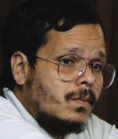

Alisson de Oliveira é Bacharel em Gestão e Análise Ambiental pela Universidade Federal de São Carlos (UFSCar) desde 2021 e Mestre em Sensoriamento Remoto pelo Instituto Nacional de Pesquisas Espaciais (INPE) desde 2024. Atualmente está no terceiro ano do doutorando em Sensoriamento Remoto no INPE, onde desenvolve pesquisas voltadas à análise ambiental utilizando dados de sensoriamento remoto e *machine learning*, como foco na utilização dos satélites brasileiros CBERS-4, CBERS-4A e AMAZONIA-1